In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
import shap

In [2]:
# Load model
best_rf = joblib.load("Best_model.pkl")

features = ["NDVI","EVI","NDMI","NDWI","LST","Rainfall","Rainfall_lag1"]

print("Model and features loaded successfully")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model and features loaded successfully


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HalvingGridSearchCV from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
df = pd.read_csv("final.csv")

# sort (VERY IMPORTANT)
df = df.sort_values(by=["point_id", "Year", "Month"]).reset_index(drop=True)

In [4]:
train_df = df[df["Year"] <= 2023]
test_df  = df[df["Year"] >= 2024]

In [5]:
def create_sequences(data, window=6):

    X, y = [], []
    years, months, pids = [], [], []

    for pid in data["point_id"].unique():
        temp = data[data["point_id"] == pid]

        for i in range(window, len(temp)):
            X.append(temp[features].iloc[i-window:i].values)
            y.append(temp["CHS"].iloc[i])

            years.append(temp["Year"].iloc[i])
            months.append(temp["Month"].iloc[i])
            pids.append(pid)

    return np.array(X), np.array(y), years, months, pids


X_test, y_test, test_years, test_months, test_pids = create_sequences(test_df)

In [6]:
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Shape:", X_test_flat.shape)

Shape: (296, 42)


In [7]:
print(best_rf.n_features_in_)

42


In [8]:
y_pred = best_rf.predict(X_test_flat)

print("Predictions completed")

Predictions completed


In [9]:
pred_df = pd.DataFrame({
    "point_id": test_pids,
    "Year": test_years,
    "Month": test_months,
    "Actual_CHS": y_test,
    "Predicted_CHS": y_pred
})

pred_df.to_csv("predictions.csv", index=False)

print("Predictions saved!")

Predictions saved!


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
corr = np.corrcoef(y_test, y_pred)[0,1]

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Correlation:", corr)

RMSE: 0.10170930436365239
MAE: 0.07391732918048365
R2: 0.6018743909688563
Correlation: 0.7830543990090468


In [11]:
results = {
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "Correlation": corr
}

with open("final_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Results saved")

Results saved


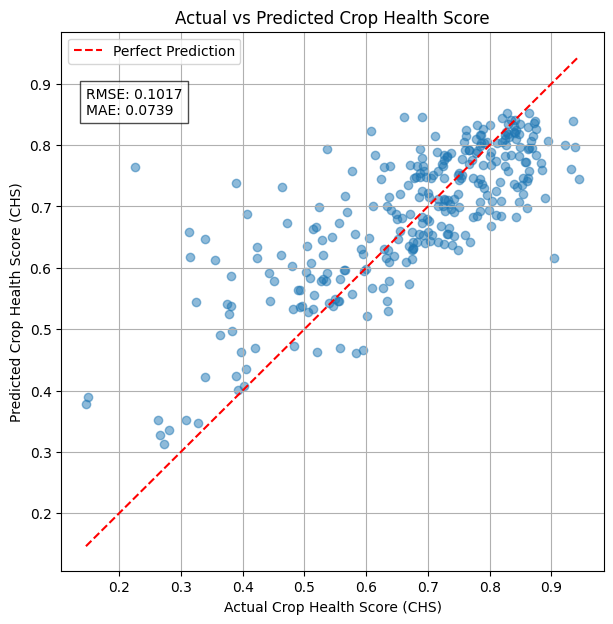

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")

# Metrics text
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
mae = np.mean(np.abs(y_test - y_pred))

plt.text(min_val, max_val*0.9,
         f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}",
         bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel("Actual Crop Health Score (CHS)")
plt.ylabel("Predicted Crop Health Score (CHS)")
plt.title("Actual vs Predicted Crop Health Score")
plt.legend()
plt.grid(True)

plt.show()

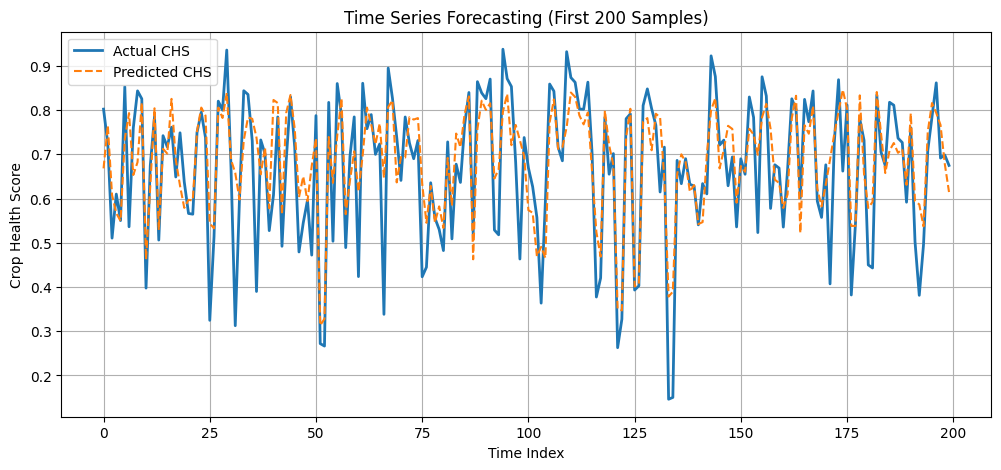

In [13]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual CHS", linewidth=2)
plt.plot(y_pred[:200], label="Predicted CHS", linestyle="--")

plt.xlabel("Time Index")
plt.ylabel("Crop Health Score")
plt.title("Time Series Forecasting (First 200 Samples)")
plt.legend()
plt.grid(True)

plt.show()

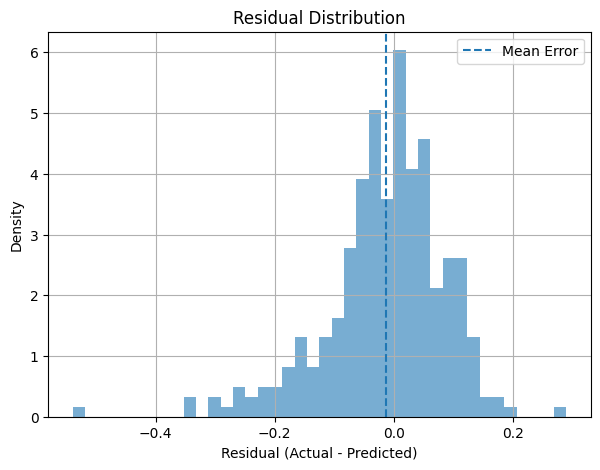

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=40, density=True, alpha=0.6)

# Mean line
plt.axvline(np.mean(residuals), linestyle='--', label="Mean Error")

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.title("Residual Distribution")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
best_model = best_rf.best_estimator_

importances = best_model.feature_importances_

feature_names = []
for t in range(6):
    for f in features:
        feature_names.append(f"{f}_t-{6-t}")

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

fi_df.to_csv("feature_importance.csv", index=False)

print(fi_df.head(10))

         Feature  Importance
15       EVI_t-4    0.231841
16      NDMI_t-4    0.092860
21      NDVI_t-3    0.042263
22       EVI_t-3    0.041676
14      NDVI_t-4    0.041450
37      NDMI_t-1    0.031629
32       LST_t-2    0.030052
40  Rainfall_t-1    0.028973
24      NDWI_t-3    0.026865
29       EVI_t-2    0.023653


In [16]:
import shap

In [17]:
best_model = best_rf.best_estimator_

In [18]:
explainer = shap.TreeExplainer(best_model)

In [19]:
X_sample = X_test_flat[:1000]

shap_values = explainer.shap_values(X_sample)

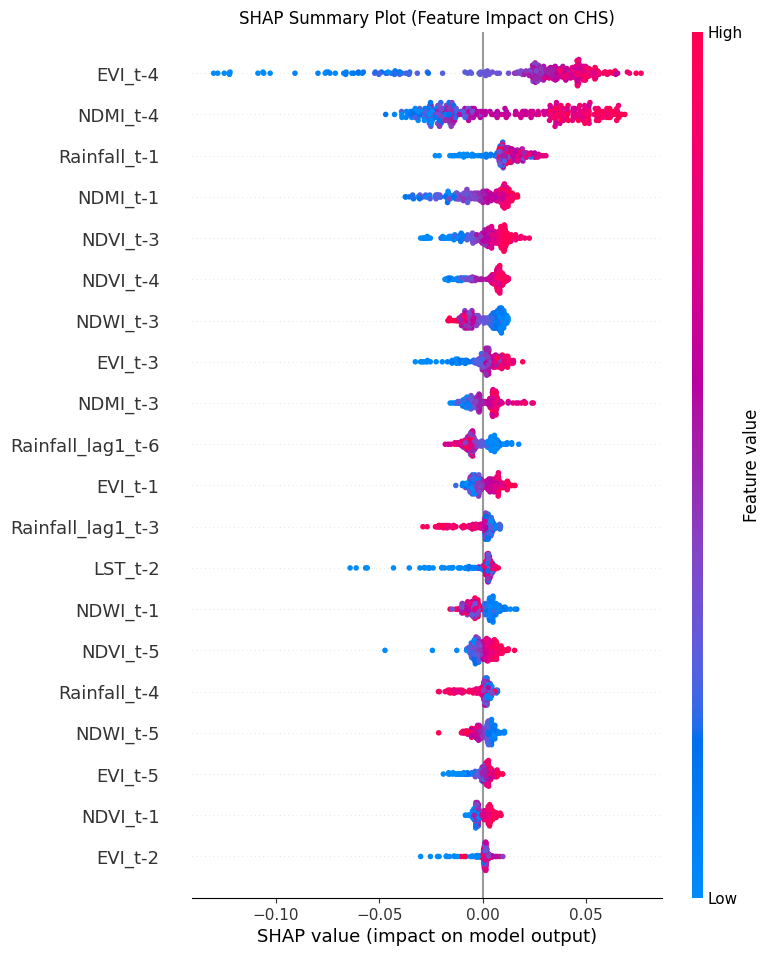

In [20]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary Plot (Feature Impact on CHS)")

plt.show()

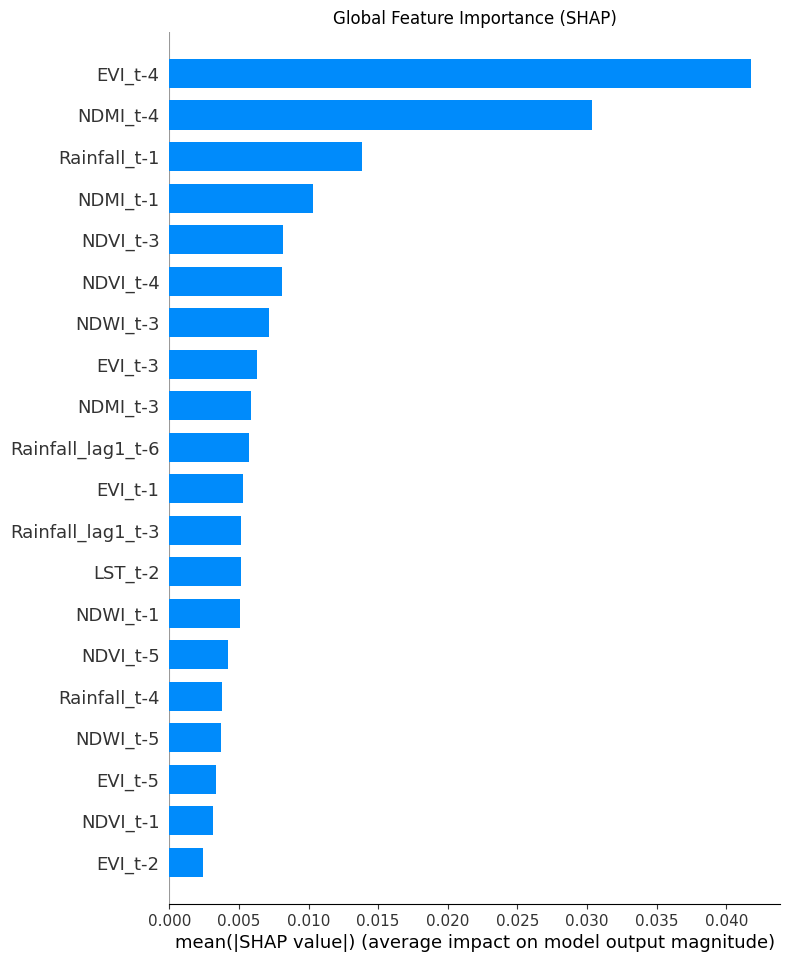

In [21]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    feature_names=feature_names,
    show=False
)
plt.title("Global Feature Importance (SHAP)")
plt.show()

In [22]:
import shap
shap.initjs()

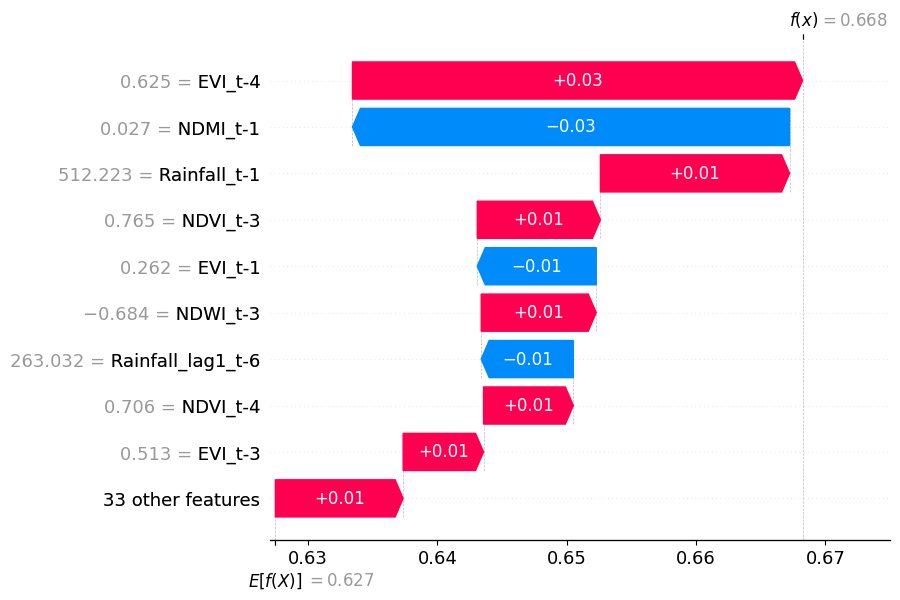

In [23]:
sample_idx = 0

expl = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_sample[sample_idx],
    feature_names=feature_names
)

shap.plots.waterfall(expl)

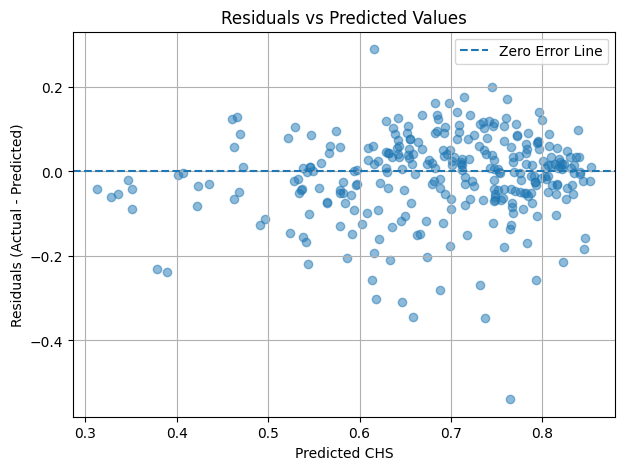

In [24]:
plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--', label="Zero Error Line")

plt.xlabel("Predicted CHS")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.legend()
plt.grid(True)

plt.show()

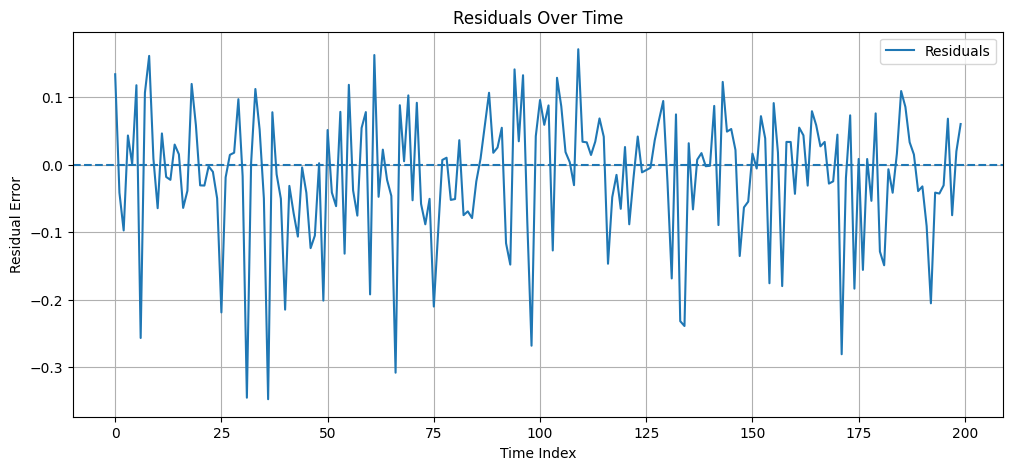

In [25]:
plt.figure(figsize=(12,5))

plt.plot(residuals[:200], label="Residuals")
plt.axhline(0, linestyle='--')

plt.xlabel("Time Index")
plt.ylabel("Residual Error")
plt.title("Residuals Over Time")
plt.legend()
plt.grid(True)

plt.show()

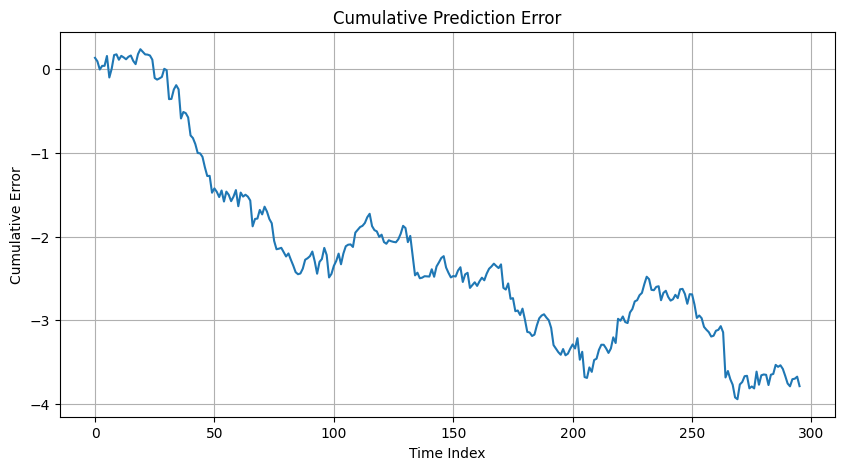

In [26]:
cum_error = np.cumsum(residuals)

plt.figure(figsize=(10,5))
plt.plot(cum_error)

plt.xlabel("Time Index")
plt.ylabel("Cumulative Error")
plt.title("Cumulative Prediction Error")
plt.grid(True)

plt.show()

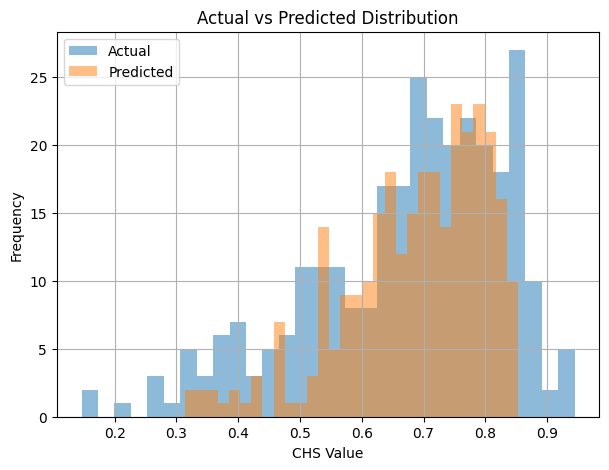

In [27]:
plt.figure(figsize=(7,5))

plt.hist(y_test, bins=30, alpha=0.5, label="Actual")
plt.hist(y_pred, bins=30, alpha=0.5, label="Predicted")

plt.xlabel("CHS Value")
plt.ylabel("Frequency")
plt.title("Actual vs Predicted Distribution")
plt.legend()
plt.grid(True)

plt.show()

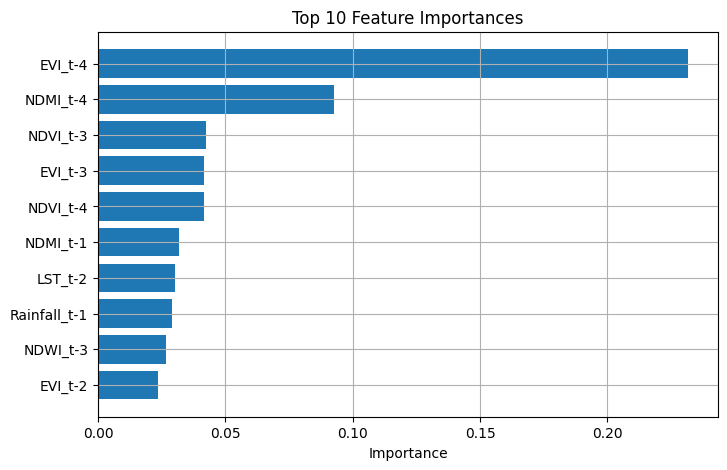

In [28]:
top_n = 10

plt.figure(figsize=(8,5))

top_features = fi_df.head(top_n)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.grid(True)

plt.show()

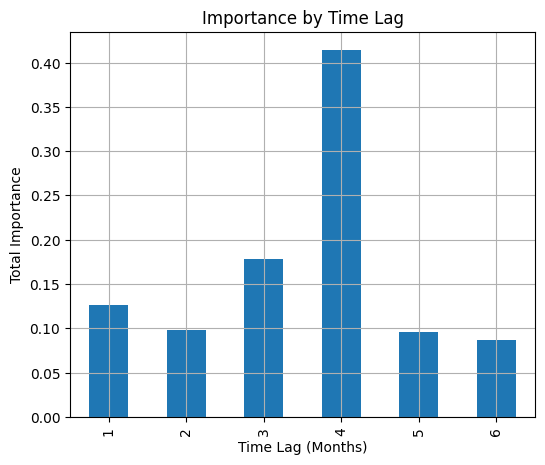

In [29]:
fi_df["Lag"] = fi_df["Feature"].apply(lambda x: x.split("_t-")[1])
lag_importance = fi_df.groupby("Lag")["Importance"].sum()

plt.figure(figsize=(6,5))
lag_importance.sort_index().plot(kind="bar")

plt.xlabel("Time Lag (Months)")
plt.ylabel("Total Importance")
plt.title("Importance by Time Lag")
plt.grid(True)

plt.show()

In [30]:
features = ["NDVI","EVI","NDMI","NDWI","LST","Rainfall","Rainfall_lag1"]

In [31]:
import pandas as pd

coords_df = pd.DataFrame({
    "point_id": list(range(15)),
    "lat": [
        33.848806, 33.80, 33.75, 33.70, 33.65,
        33.60, 33.50, 33.40, 33.30, 33.20,
        33.10, 33.00, 32.90, 32.80, 32.663750
    ],
    "lon": [
        74.885750, 74.88, 74.87, 74.86, 74.85,
        74.84, 74.83, 74.82, 74.81, 74.80,
        74.79, 74.78, 74.77, 74.76, 74.816806
    ]
})

coords_df.to_csv("point_coordinates.csv", index=False)

print(coords_df)

    point_id        lat        lon
0          0  33.848806  74.885750
1          1  33.800000  74.880000
2          2  33.750000  74.870000
3          3  33.700000  74.860000
4          4  33.650000  74.850000
5          5  33.600000  74.840000
6          6  33.500000  74.830000
7          7  33.400000  74.820000
8          8  33.300000  74.810000
9          9  33.200000  74.800000
10        10  33.100000  74.790000
11        11  33.000000  74.780000
12        12  32.900000  74.770000
13        13  32.800000  74.760000
14        14  32.663750  74.816806


In [32]:
import pandas as pd

df = pd.read_csv("final.csv")
coords_df = pd.read_csv("point_coordinates.csv")

In [33]:
latest_features = (
    df.sort_values(["point_id","Year","Month"])
      .groupby("point_id")
      .tail(1)
)

latest_features = latest_features[["point_id"] + features]

print(latest_features.head())

     point_id      NDVI       EVI      NDMI      NDWI        LST    Rainfall  \
26          0  0.672991  0.402511  0.148879 -0.630677  22.784327  217.237785   
52          1  0.285910  0.346610  0.110135 -0.217122  16.477646  142.852184   
79          2  0.445646  0.298857 -0.017826 -0.438686  27.574021  238.394916   
107         3  0.245879  0.448272  0.173853 -0.148828  24.638287  210.108042   
133         4  0.686073  0.479801  0.184173 -0.616355  27.743173  234.519947   

     Rainfall_lag1  
26      552.162470  
52      344.843026  
79      630.202705  
107     600.180630  
133     772.631859  


In [34]:
geo_df = coords_df.merge(latest_features, on="point_id")

print(geo_df)

    point_id        lat        lon      NDVI       EVI      NDMI      NDWI  \
0          0  33.848806  74.885750  0.672991  0.402511  0.148879 -0.630677   
1          1  33.800000  74.880000  0.285910  0.346610  0.110135 -0.217122   
2          2  33.750000  74.870000  0.445646  0.298857 -0.017826 -0.438686   
3          3  33.700000  74.860000  0.245879  0.448272  0.173853 -0.148828   
4          4  33.650000  74.850000  0.686073  0.479801  0.184173 -0.616355   
5          5  33.600000  74.840000  0.706858  0.610935  0.321075 -0.618883   
6          6  33.500000  74.830000  0.216803  0.128123 -0.015444 -0.230809   
7          7  33.400000  74.820000  0.597088  0.511841  0.110018 -0.495938   
8          8  33.300000  74.810000  0.718369  0.465190  0.257061 -0.652002   
9          9  33.200000  74.800000  0.429731  0.189160 -0.006089 -0.377205   
10        10  33.100000  74.790000  0.745763  0.391216  0.139990 -0.643034   
11        11  33.000000  74.780000  0.726608  0.490433  0.199768

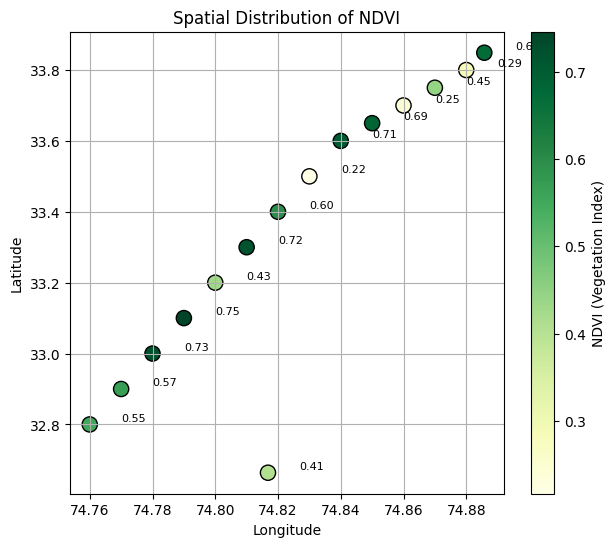

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sc = plt.scatter(
    geo_df["lon"],
    geo_df["lat"],
    c=geo_df["NDVI"],
    cmap="YlGn",
    s=120,
    edgecolor="black"
)

cbar = plt.colorbar(sc)
cbar.set_label("NDVI (Vegetation Index)")

for _, row in geo_df.iterrows():
    plt.text(
        row["lon"] + 0.01,
        row["lat"] + 0.01,
        f"{row['NDVI']:.2f}",
        fontsize=8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of NDVI")

plt.grid(True)
plt.show()

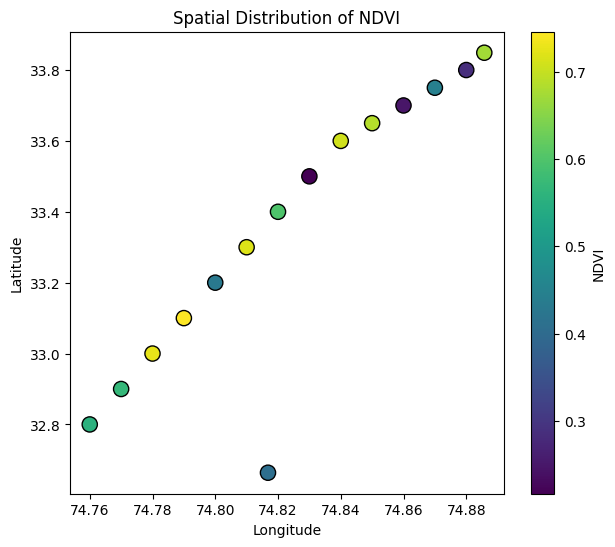

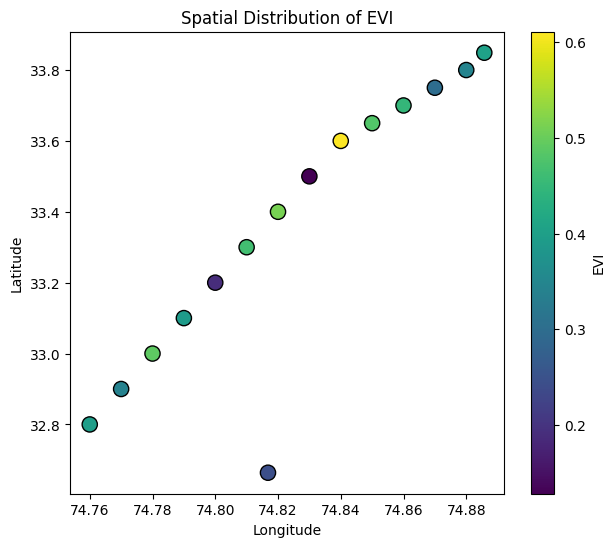

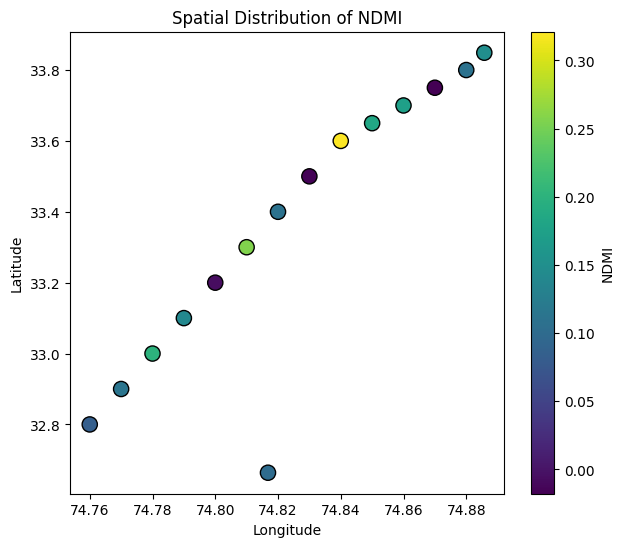

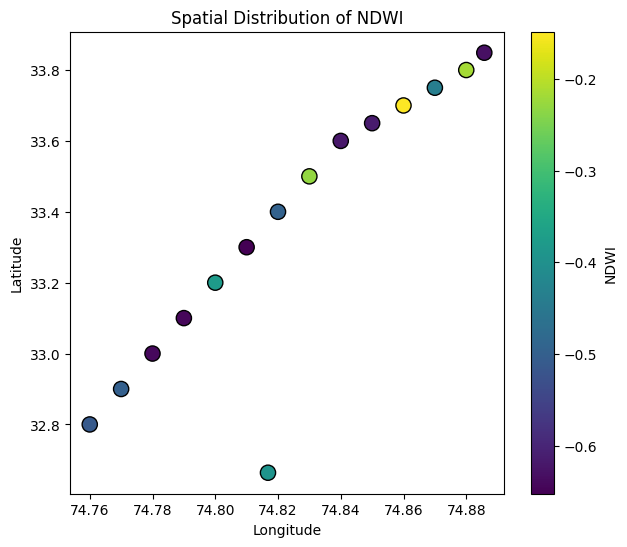

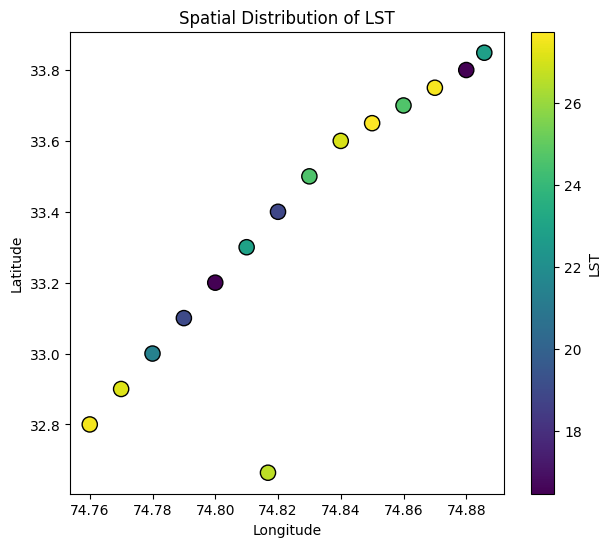

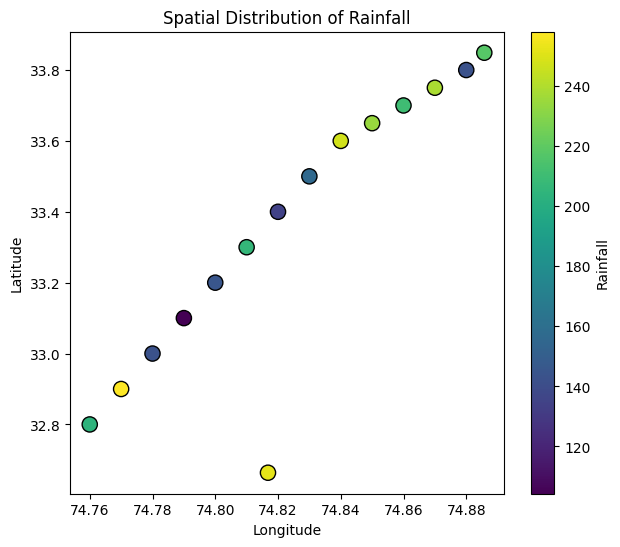

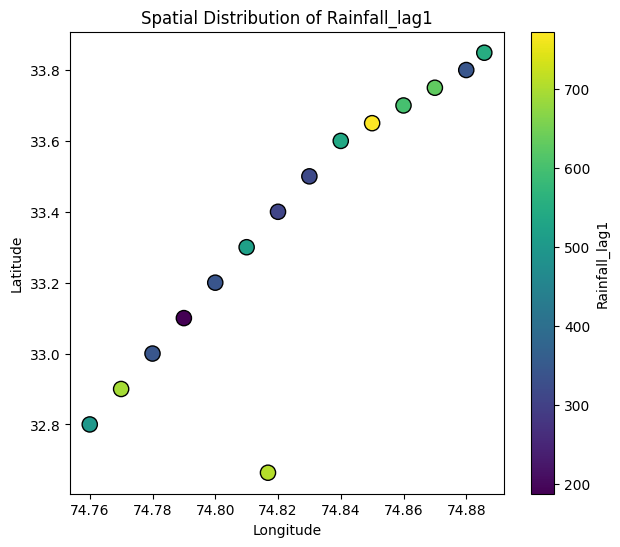

In [36]:
for f in features:
    plt.figure(figsize=(7,6))

    sc = plt.scatter(
        geo_df["lon"],
        geo_df["lat"],
        c=geo_df[f],
        cmap="viridis",
        s=120,
        edgecolor="black"
    )

    plt.colorbar(sc, label=f)
    plt.title(f"Spatial Distribution of {f}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.show()

In [37]:
import folium
import branca.colormap as cm

colormap = cm.linear.viridis.scale(
    geo_df["NDVI"].min(),
    geo_df["NDVI"].max()
)

m = folium.Map(
    location=[geo_df["lat"].mean(), geo_df["lon"].mean()],
    zoom_start=7
)

for _, row in geo_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=colormap(row["NDVI"]),
        fill=True,
        fill_opacity=0.8,
        popup=(
            f"Point ID: {row['point_id']}<br>"
            f"NDVI: {row['NDVI']:.3f}<br>"
            f"EVI: {row['EVI']:.3f}<br>"
            f"NDMI: {row['NDMI']:.3f}"
        )
    ).add_to(m)

colormap.add_to(m)
m.save("ndvi_interactive_map.html")

In [38]:
merged = pred_df.merge(coords_df, on="point_id")

print(merged.head())
print("Rows after merge:", len(merged))

   point_id  Year  Month  Actual_CHS  Predicted_CHS        lat       lon
0         0  2025      8    0.802177       0.668231  33.848806  74.88575
1         0  2025      9    0.723706       0.765331  33.848806  74.88575
2         1  2025      9    0.510554       0.608143  33.800000  74.88000
3         2  2025      8    0.610068       0.566884  33.750000  74.87000
4         2  2025      9    0.550226       0.549462  33.750000  74.87000
Rows after merge: 22


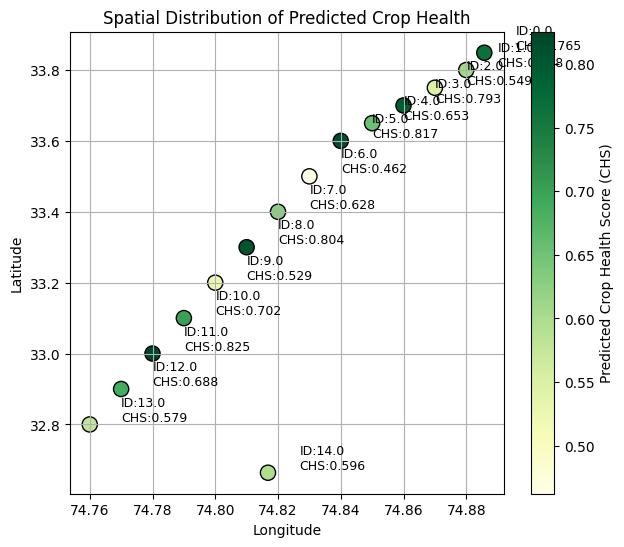

In [39]:
import matplotlib.pyplot as plt

# Ensure we are using latest prediction per point
latest = merged.sort_values(["Year", "Month"]).groupby("point_id").tail(1)

plt.figure(figsize=(7,6))

sc = plt.scatter(
    latest["lon"],
    latest["lat"],
    c=latest["Predicted_CHS"],
    cmap="YlGn",   # green = healthy
    s=120,
    edgecolor="black"
)

cbar = plt.colorbar(sc)
cbar.set_label("Predicted Crop Health Score (CHS)")

# annotate points (VERY IMPORTANT for small dataset)
for _, row in latest.iterrows():
    plt.text(
        row["lon"] + 0.01,
        row["lat"] + 0.01,
        f"ID:{row['point_id']}\nCHS:{row['Predicted_CHS']:.3f}",
        fontsize=9
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Predicted Crop Health")

plt.grid(True)

plt.show()

In [40]:
import folium
import branca.colormap as cm

# FIXED colormap
colormap = cm.linear.YlGn_09.scale(
    latest["Predicted_CHS"].min(),
    latest["Predicted_CHS"].max()
)

m = folium.Map(
    location=[latest["lat"].mean(), latest["lon"].mean()],
    zoom_start=7
)

for _, row in latest.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=8,
        color=colormap(row["Predicted_CHS"]),
        fill=True,
        fill_opacity=0.8,
        popup=(
            f"Point ID: {row['point_id']}<br>"
            f"CHS: {row['Predicted_CHS']:.3f}"
        )
    ).add_to(m)

colormap.add_to(m)

m.save("crop_health_map.html")

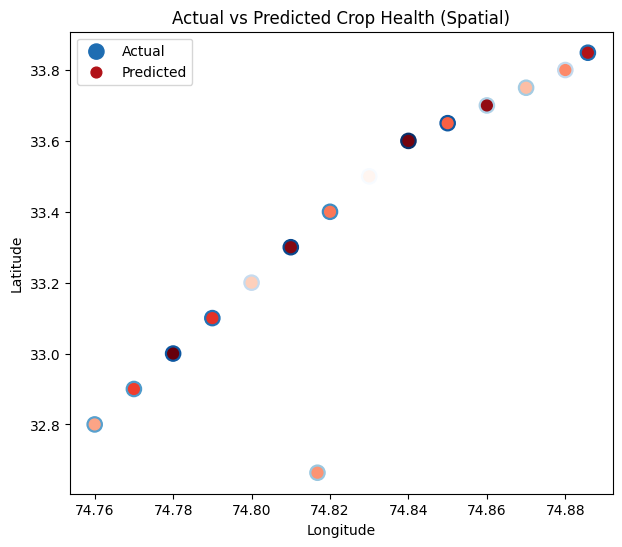

In [41]:
plt.figure(figsize=(7,6))

plt.scatter(
    latest["lon"],
    latest["lat"],
    c=latest["Actual_CHS"],
    cmap="Blues",
    s=120,
    label="Actual"
)

plt.scatter(
    latest["lon"],
    latest["lat"],
    c=latest["Predicted_CHS"],
    cmap="Reds",
    s=60,
    label="Predicted"
)

plt.legend()
plt.title("Actual vs Predicted Crop Health (Spatial)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [42]:
features = ["NDVI","EVI","NDMI","NDWI","LST","Rainfall","Rainfall_lag1"]

In [43]:
import pandas as pd

df = pd.read_csv("final.csv")
coords_df = pd.read_csv("point_coordinates.csv")

In [44]:
feature_df = (
    df.sort_values(["point_id","Year","Month"])
      .groupby("point_id")
      .tail(1)
)[["point_id"] + features]

In [45]:
merged = coords_df.merge(feature_df, on="point_id")

print(merged.head())

   point_id        lat       lon      NDVI       EVI      NDMI      NDWI  \
0         0  33.848806  74.88575  0.672991  0.402511  0.148879 -0.630677   
1         1  33.800000  74.88000  0.285910  0.346610  0.110135 -0.217122   
2         2  33.750000  74.87000  0.445646  0.298857 -0.017826 -0.438686   
3         3  33.700000  74.86000  0.245879  0.448272  0.173853 -0.148828   
4         4  33.650000  74.85000  0.686073  0.479801  0.184173 -0.616355   

         LST    Rainfall  Rainfall_lag1  
0  22.784327  217.237785     552.162470  
1  16.477646  142.852184     344.843026  
2  27.574021  238.394916     630.202705  
3  24.638287  210.108042     600.180630  
4  27.743173  234.519947     772.631859  


In [46]:
import numpy as np

lon_min, lat_min = 74.5, 32.5
lon_max, lat_max = 75.9, 33.5

nx, ny = 200, 200   # resolution

lon_vals = np.linspace(lon_min, lon_max, nx)
lat_vals = np.linspace(lat_min, lat_max, ny)

grid = [(lat, lon) for lat in lat_vals for lon in lon_vals]
grid_df = pd.DataFrame(grid, columns=["lat","lon"])

In [47]:
from scipy.spatial import cKDTree

tree = cKDTree(merged[["lat","lon"]].values)

_, idx = tree.query(grid_df[["lat","lon"]].values)

for f in features:
    grid_df[f] = merged.iloc[idx][f].values

In [48]:
def build_input(row):
    return np.tile(row[features].values, 6)

X_grid = np.array([build_input(row) for _, row in grid_df.iterrows()])

In [49]:
import joblib

model = joblib.load("Best_model.pkl")

grid_df["CHS"] = model.predict(X_grid)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HalvingGridSearchCV from version 1.7.1 when using version 1.6.1. This might lead t

In [50]:
Z = grid_df["CHS"].values.reshape(ny, nx)

Z_norm = (Z - Z.min()) / (Z.max() - Z.min())

In [51]:
import matplotlib.pyplot as plt

plt.imsave("chs_map.png", Z_norm, cmap="RdYlGn")

In [52]:
import folium

m = folium.Map(
    location=[33.0, 75.0],
    zoom_start=8,
    tiles="Esri.WorldImagery"
)

folium.raster_layers.ImageOverlay(
    image="chs_map.png",
    bounds=[[32.5, 74.5], [33.5, 75.9]],
    opacity=0.6
).add_to(m)

m.save("Jammu_CHS_Map.html")

In [79]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='gee-jammu-dissertation')

In [80]:
region = ee.Geometry.Rectangle([74.5, 32.5, 75.9, 33.5])

In [81]:
def select_bands(img):
    return img.select(['B2','B3','B4','B8','B11'])

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR")
    .filterBounds(region)
    .filterDate('2024-01-01', '2024-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .map(select_bands)
    .median()
)

# Vegetation indices
ndvi = s2.normalizedDifference(['B8','B4']).rename('NDVI').toFloat()

evi = s2.expression(
    '2.5*((NIR - RED)/(NIR + 6*RED - 7.5*BLUE + 1))',
    {
        'NIR': s2.select('B8'),
        'RED': s2.select('B4'),
        'BLUE': s2.select('B2')
    }
).rename('EVI').toFloat()

ndmi = s2.normalizedDifference(['B8','B11']).rename('NDMI').toFloat()
ndwi = s2.normalizedDifference(['B3','B8']).rename('NDWI').toFloat()

In [82]:
lst = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(region)
    .filterDate('2024-01-01', '2024-03-31')
    .select('LST_Day_1km')
    .mean()
)

# Convert to Celsius
lst = lst.multiply(0.02).subtract(273.15).rename('LST').toFloat()

In [83]:
rain = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(region)
    .filterDate('2024-01-01', '2024-03-31')
    .sum()
    .rename('Rainfall')
    .toFloat()
)

In [84]:
rain_lag = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(region)
    .filterDate('2023-10-01', '2023-12-31')
    .sum()
    .rename('Rainfall_lag1')
    .toFloat()
)

In [85]:
def resample(img):
    return img.resample('bilinear').reproject(
        crs=s2.projection(),
        scale=30
    )

lst = resample(lst)
rain = resample(rain)
rain_lag = resample(rain_lag)

In [86]:
feature_stack = ee.Image.cat([
    ndvi, evi, ndmi, ndwi,
    lst, rain, rain_lag
]).toFloat()

In [87]:
task = ee.batch.Export.image.toDrive(
    image=feature_stack,
    description='Jammu_All_Features',
    folder='GEE_Exports',
    fileNamePrefix='jammu_full_features',
    region=region,
    scale=30,
    maxPixels=1e13,
    fileFormat='GeoTIFF',
    formatOptions={'cloudOptimized': True}
)

task.start()

print("✅ Export started")

✅ Export started


In [88]:
import rasterio
import numpy as np

src = rasterio.open("/content/drive/MyDrive/GEE_Exports/jammu_full_features.tif")

data = src.read().astype("float32")

H, W = data.shape[1], data.shape[2]

print("Shape:", data.shape)

Shape: (7, 3719, 5196)


In [89]:
pixels = data.reshape(data.shape[0], -1).T

In [90]:
import joblib

model = joblib.load("Best_model.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HalvingGridSearchCV from version 1.7.1 when using version 1.6.1. This might lead t

In [91]:
chunk_size = 100000   # bigger = faster (if RAM allows)
preds = []

for i in range(0, pixels.shape[0], chunk_size):
    chunk = pixels[i:i+chunk_size]

    # 🔥 FAST vectorized time expansion
    X_chunk = np.repeat(chunk, 6, axis=1)

    y_chunk = model.predict(X_chunk)

    preds.append(y_chunk)

chs = np.concatenate(preds)

In [92]:
chs_img = chs.reshape(H, W)

In [93]:
low = np.percentile(chs_img, 5)
high = np.percentile(chs_img, 95)

chs_norm = (chs_img - low) / (high - low)
chs_norm = np.clip(chs_norm, 0, 1)

In [94]:
import matplotlib.pyplot as plt

plt.imsave("CHS_final.png", chs_norm, cmap="RdYlGn")

In [96]:
import folium
import branca.colormap as cm

In [103]:
m = folium.Map(
    location=[33.0, 75.0],
    zoom_start=8,
    tiles="OpenStreetMap",
    control_scale=True   # ✅ THIS is the real scale bar
)

In [104]:
folium.raster_layers.ImageOverlay(
    image="CHS_final.png",
    bounds=[[32.5, 74.5], [33.5, 75.9]],
    opacity=0.65,
    name="Crop Health Score"
).add_to(m)

In [105]:
colormap = cm.LinearColormap(
    colors=['red', 'yellow', 'green'],
    vmin=0,
    vmax=1
)

colormap.caption = "Crop Health Score (CHS)"
colormap.add_to(m)

In [106]:
north_arrow = '''
<div style="
position: fixed;
top: 60px; left: 20px;
width: 80px; height: 80px;
z-index:9999;
font-size:30px;
font-weight:bold;
text-align:center;
">
↑<br>N
</div>
'''
m.get_root().html.add_child(folium.Element(north_arrow))

In [107]:
title_html = '''
<h3 align="center" style="font-size:20px"><b>
Spatial Crop Health Prediction Map (Jammu Region)
</b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))

In [108]:
folium.LayerControl().add_to(m)

In [109]:
m.save("CHS_Publication_Map.html")